In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

BEHAVIORS_PATH = "../smallDataset/MINDsmall_train/behaviors.tsv"

# MIND behaviors.tsv has 5 tab-separated columns, no header in the file.
cols = ["impression_id", "user_id", "time", "history", "impressions"]
beh = pd.read_csv(BEHAVIORS_PATH, sep="\t", header=None, names=cols)

beh.head(), beh.shape

(   impression_id user_id                   time  \
 0              1  U13740  11/11/2019 9:05:58 AM   
 1              2  U91836  11/12/2019 6:11:30 PM   
 2              3  U73700  11/14/2019 7:01:48 AM   
 3              4  U34670  11/11/2019 5:28:05 AM   
 4              5   U8125  11/12/2019 4:11:21 PM   
 
                                              history  \
 0  N55189 N42782 N34694 N45794 N18445 N63302 N104...   
 1  N31739 N6072 N63045 N23979 N35656 N43353 N8129...   
 2  N10732 N25792 N7563 N21087 N41087 N5445 N60384...   
 3  N45729 N2203 N871 N53880 N41375 N43142 N33013 ...   
 4                        N10078 N56514 N14904 N33740   
 
                                          impressions  
 0                                  N55689-1 N35729-0  
 1  N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...  
 2  N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...  
 3                N35729-0 N33632-0 N49685-1 N27581-0  
 4  N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...  ,
 (156

# Interpretation of the table behaviours.tsv

1
U13740
11/11/2019 9:05:58 AM	
N55189 N42782 N34694 N45794 N18445 N63302 N10414 N19347 N31801	
N55689-1 N35729-0

* This is a typical row. Here we have the ImpressionID as 1 (Meaning the system showed this user a small set of candidate articles at this time), 

* U13740 as the user ID,
* Time as the timestamp (News is time-sensitive and we must avoid training on future clicks)
* N55189 all the way to N31801 are the articles the user previously clicked on before this impression
* The history length in this case is 9 and this is the user profile and is what we use for content-based methods
* N55689-1 and N35729-0 is the most important part, each is formatted as newsID - ClickLabel, with 1 meaning user clicked and 0 meaning user did not click



In [2]:
n_impressions = len(beh)
n_users = beh["user_id"].nunique()

print("Impressions:", n_impressions)
print("Unique users:", n_users)

Impressions: 156965
Unique users: 50000


* The dataset contains 156965 impressions and an impression means: The recommender system showed a set of candidate news articles to a user at a specific time. There were 50000 users meaning that each user appears in about 3 impressions.

* IMPORTANT INSIGHT: This means the users are extremely sparse and many users appear only a few times. This makes user-based collaborative filtering more difficult, cold-start is common and content-based methods becomes important.

In [3]:
beh["impression_size"] = beh["impressions"].apply(lambda x: len(x.split()))

print("Average candidates per impression:", beh["impression_size"].mean())

Average candidates per impression: 37.22768770107986


* Means each time the system recommended articles to a user, about 37 articles were shown. So each user gets about 37 article candidates and typically clicks on only 1 of them. This could be a baseline of 1/37.
* So if we use metrics like MRR, nDCG@5 and nDCG@10, means that rank 1 is perfect and 37 is the worst score.

In [4]:
def parse_impressions(impr_str):
    """
    Returns (news_ids, labels) from 'N123-0 N456-1 ...'
    """
    if pd.isna(impr_str) or impr_str == "":
        return [], []
    parts = impr_str.split()
    news_ids = []
    labels = []
    for p in parts:
        # split from the right in case of unexpected dashes
        nid, lbl = p.rsplit("-", 1)
        news_ids.append(nid)
        labels.append(int(lbl))
    return news_ids, labels


def parse_history(hist_str):
    """
    Returns list of news ids from 'N12 N34 N56 ...'
    """
    if pd.isna(hist_str) or hist_str == "":
        return []
    return hist_str.split()


In [5]:
parsed = beh["impressions"].apply(parse_impressions)
beh["cand_news"] = parsed.apply(lambda x: x[0])
beh["cand_labels"] = parsed.apply(lambda x: x[1])

beh["impression_size"] = beh["cand_news"].apply(len)
beh["n_clicks"] = beh["cand_labels"].apply(sum)

beh[["impressions", "impression_size", "n_clicks"]].head(10)

,impressions,impression_size,n_clicks
0,N55689-1 N35729-0,2,1
1,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...,11,1
2,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...,36,1
3,N35729-0 N33632-0 N49685-1 N27581-0,4,1
4,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...,69,1
5,N21119-1 N53696-0 N33619-1 N25722-0 N2869-0,5,2
6,N51346-0 N33848-0 N15132-0 N10688-0 N6342-0 N6...,173,1
7,N7821-0 N24898-0 N12029-0 N13579-0 N42977-0 N3...,7,1
8,N51048-1 N64094-0 N13907-0 N39010-0,4,1
9,N53585-1 N55689-0,2,1


Here we have an overview of some select rows where we can see that each row represents a user that has been presented with various articles (impressions) and whether or not they clicked on any of them. Here we can see that some users get presented a list of articles and click on several. Others show that it's very sparse with 173 impressions and only 1 click

In [6]:
total_clicks = beh["n_clicks"].sum()
total_candidates = beh["impression_size"].sum()

print("Total clicks:", total_clicks)
print("Total candidate items shown:", total_candidates)

Total clicks: 236344
Total candidate items shown: 5843444


The total number of times users clicked an article across all impressions and the total number of articles shown to users whether clicked or not

In [7]:
ctr = total_clicks / total_candidates if total_candidates > 0 else float("nan")
print("CTR (clicks / shown candidates):", ctr)

CTR (clicks / shown candidates): 0.040446010948338


The click through rate means out of all the articles shown to users, only around 4% are clicked

This means that we should NOT use accuracy because if a model predicts "no click" for everything, it will get 96% accuracy which doesn't make sense. Emphasis on ranking metrics and ranking the top candidates via MRR, nDCG@5 and nDCG@10 and the training needs to learn to distinguish rare positives from many negatives.

In [8]:
print(beh["impression_size"].describe())

count    156965.000000
mean         37.227688
std          38.594148
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impression_size, dtype: float64


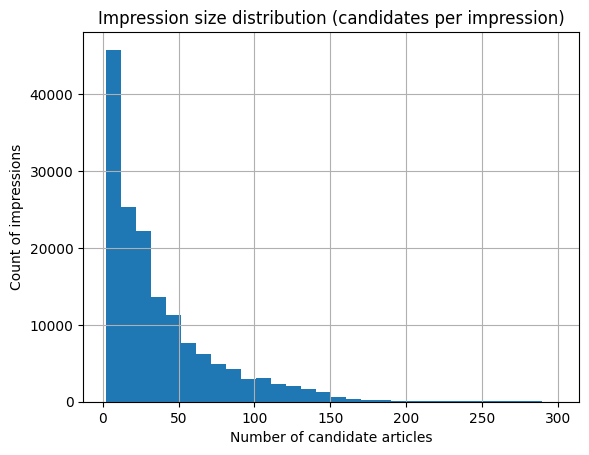

In [9]:
beh["impression_size"].hist(bins=30)
plt.title("Impression size distribution (candidates per impression)")
plt.xlabel("Number of candidate articles")
plt.ylabel("Count of impressions")
plt.show()

We can observe here that the dataset is heavily skewed and that it varies from 2 article impressions for a user to up to 299 article impressions for a user

In [10]:
one_click = (beh["n_clicks"] == 1).mean()
zero_click = (beh["n_clicks"] == 0).mean()
multi_click = (beh["n_clicks"] > 1).mean()

print("Fraction with 0 clicks:", zero_click)
print("Fraction with exactly 1 click:", one_click)
print("Fraction with >1 clicks:", multi_click)

print("Counts:")
print(beh["n_clicks"].value_counts().sort_index().head(10))

Fraction with 0 clicks: 0.0
Fraction with exactly 1 click: 0.7255630236039882
Fraction with >1 clicks: 0.27443697639601183
Counts:
n_clicks
1     113888
2      25571
3       9263
4       3975
5       1957
6        942
7        515
8        296
9        198
10       117
Name: count, dtype: int64


Here we can see that each article impression has had at least 1 click and there are no articles that haven't gotten at LEAST 1 click. We can also observe that it's skewed skewed as 72.5% of all article impressions have received precisely 1 click and at most have received 10 clicks.

While the majority of impressions contain a single click, a substantial number include multiple clicks, suggesting that the recommendation task is inherently multi-label. This reinforces the importance of ranking metrics such as nDCG, which account for multiple relevant items.

In [11]:
beh["history_list"] = beh["history"].apply(parse_history)
beh["history_len"] = beh["history_list"].apply(len)

print(beh["history_len"].describe())
print()
print("Fraction with empty history:", (beh["history_len"] == 0).mean())

count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history_len, dtype: float64

Fraction with empty history: 0.02062880259930558


History = Articles the user clicked BEFORE a specific moment. Remember that an impression is one recommended event. Again, at this moment, a user is shown a list of candidate articles. So on average in the results above, users have read 32 articles before being shown a list of recommended articles.

We also observe that around 2% of users didn't have any history of looking through articles at all so that we have to handle these cold start cases. 

In [12]:
beh["clicks"] = beh["impressions"].apply(
    lambda x: sum(int(i.split("-")[1]) for i in x.split())
)

print("Average clicks per impression:", beh["clicks"].mean())
print(beh["clicks"].value_counts().head())

Average clicks per impression: 1.5057114643391838
clicks
1    113888
2     25571
3      9263
4      3975
5      1957
Name: count, dtype: int64


On average, each time an impression (recommendation list) is shown, the user clicks about 1.5 articles.

This means that this is NOT  single label problem, where we assume that user picks ONE best item, we need to suggest a list of items and we need to rank them, as this is a RANKING problem

count    50000.000000
mean         3.139300
std          3.001026
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         62.000000
Name: count, dtype: float64


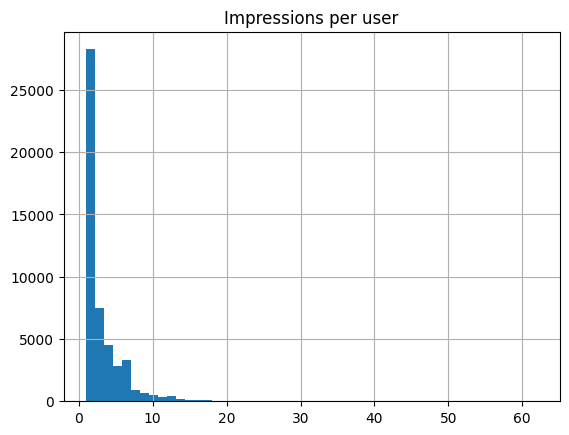

In [13]:
user_counts = beh["user_id"].value_counts()

print(user_counts.describe())

user_counts.hist(bins=50)
plt.title("Impressions per user")
plt.show()

How many impressions are there per user? We can see that most users appear in the 1 - 5 impressions per user part. This is a heavy right skewed distribution. Because each user has few interactions in the dataset, this makes collaborative filtering very hard.

In [14]:
beh["history_len"] = beh["history"].apply(
    lambda x: 0 if pd.isna(x) else len(x.split())
)

print(beh["history_len"].describe())

count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history_len, dtype: float64


count    156965.000000
mean         37.227688
std          38.594148
min           2.000000
25%          10.000000
50%          24.000000
75%          51.000000
max         299.000000
Name: impression_size, dtype: float64


<Axes: >

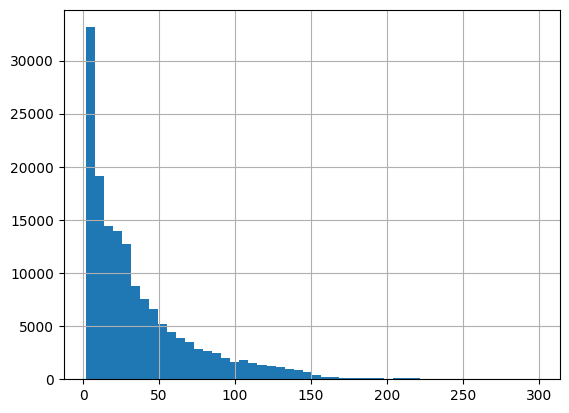

In [15]:
beh["impression_size"] = beh["impressions"].apply(lambda x: len(x.split()))

print(beh["impression_size"].describe())
beh["impression_size"].hist(bins=50)

count    156965.000000
mean          0.108544
std           0.129495
min           0.003367
25%           0.028571
50%           0.055556
75%           0.125000
max           0.750000
Name: ctr_per_impression, dtype: float64


<Axes: >

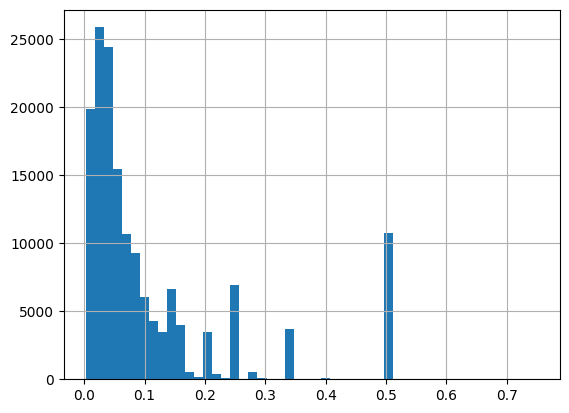

In [16]:
beh["ctr_per_impression"] = beh["clicks"] / beh["impression_size"]

print(beh["ctr_per_impression"].describe())
beh["ctr_per_impression"].hist(bins=50)

In [17]:
print("Fraction with zero clicks:", (beh["clicks"] == 0).mean())

Fraction with zero clicks: 0.0


count    7713.000000
mean       30.642292
std       136.413297
min         1.000000
25%         1.000000
50%         2.000000
75%        14.000000
max      4316.000000
dtype: float64


<Axes: >

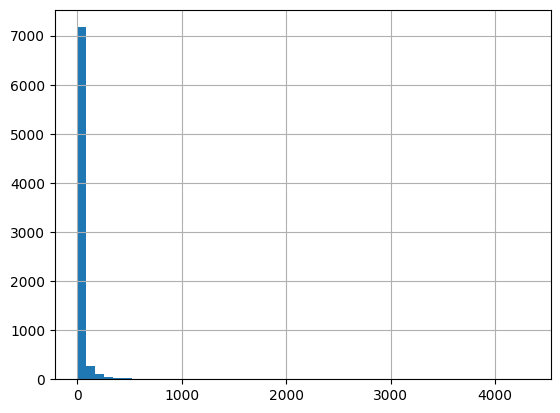

In [18]:
clicked_items = []

for imp in beh["impressions"]:
    for item in imp.split():
        article, label = item.split("-")
        if label == "1":
            clicked_items.append(article)

article_counts = Counter(clicked_items)

popularity = pd.Series(article_counts)

print(popularity.describe())
popularity.hist(bins=50)

## Temporal analysis

News is time-sensitive — a model trained on future data to predict past clicks would be invalid. Before building any model, we need to understand the date range of the dataset and whether impressions are spread evenly across time. This also informs how to do a proper chronological train/validation split.

Date range:
  Earliest impression: 2019-11-09 00:00:19
  Latest impression:   2019-11-14 23:59:13
  Span: 5 days 23:58:54



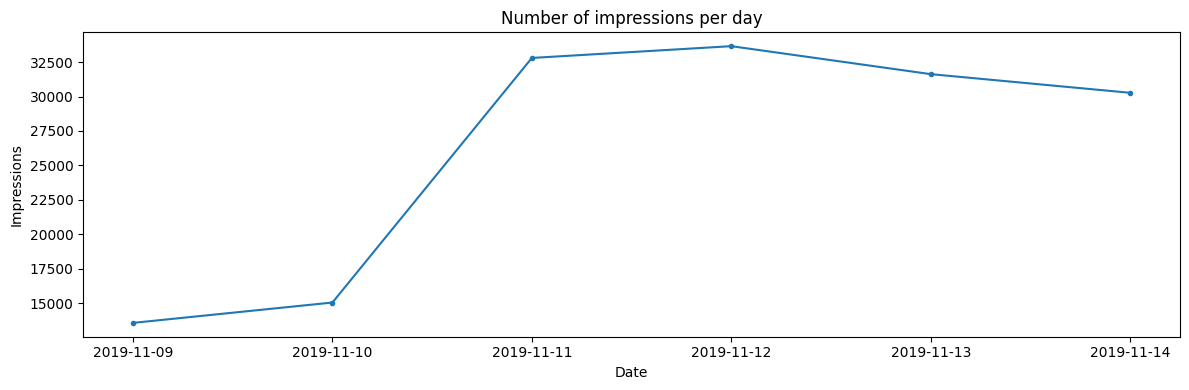

Impressions per day:
count        6.000000
mean     26160.833333
std       9262.487709
min      13570.000000
25%      18853.500000
50%      30947.000000
75%      32505.250000
max      33654.000000
dtype: float64


In [19]:
beh["timestamp"] = pd.to_datetime(beh["time"])

print("Date range:")
print("  Earliest impression:", beh["timestamp"].min())
print("  Latest impression:  ", beh["timestamp"].max())
print("  Span:", beh["timestamp"].max() - beh["timestamp"].min())
print()

# Impressions per day
beh["date"] = beh["timestamp"].dt.date
daily_counts = beh.groupby("date").size()

daily_counts.plot(figsize=(12, 4), marker="o", markersize=3)
plt.title("Number of impressions per day")
plt.xlabel("Date")
plt.ylabel("Impressions")
plt.tight_layout()
plt.show()

print("Impressions per day:")
print(daily_counts.describe())

## Position bias in impressions

In recommendation datasets, users tend to click articles that appear earlier in the list regardless of actual relevance — this is called **position bias**. If it exists here, the click labels are not purely a signal of article quality; they are also influenced by where the article was displayed. This is important to acknowledge in the report as a limitation of the ground truth labels.

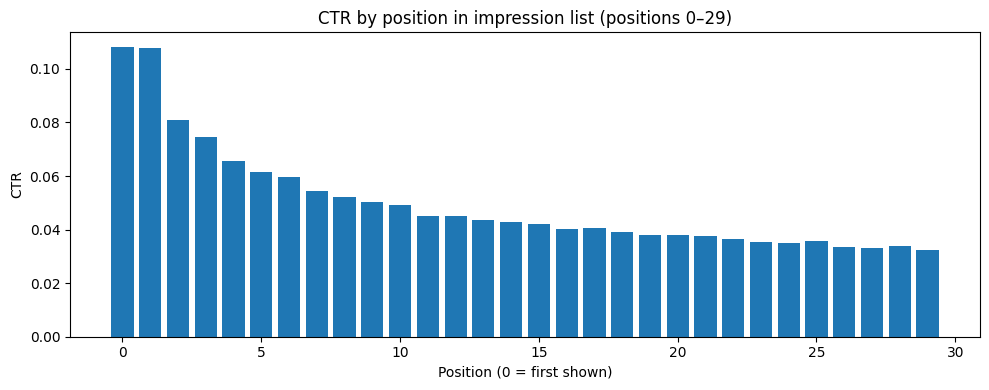

CTR at position 0 (first): 0.1082
CTR at position 9 (tenth): 0.0504
CTR at position 19 (twentieth): 0.038


In [20]:
# For each position in an impression list, compute the fraction of clicks at that position
MAX_POS = 30  # only look at the first 30 positions (most impressions are shorter)

position_clicks = Counter()
position_total = Counter()

for imp in beh["impressions"]:
    items = imp.split()
    for pos, item in enumerate(items):
        _, lbl = item.rsplit("-", 1)
        position_total[pos] += 1
        if lbl == "1":
            position_clicks[pos] += 1

positions = list(range(MAX_POS))
ctr_by_pos = [
    position_clicks[p] / position_total[p] if position_total[p] > 0 else 0
    for p in positions
]

plt.figure(figsize=(10, 4))
plt.bar(positions, ctr_by_pos)
plt.title("CTR by position in impression list (positions 0–29)")
plt.xlabel("Position (0 = first shown)")
plt.ylabel("CTR")
plt.tight_layout()
plt.show()

print("CTR at position 0 (first):", round(ctr_by_pos[0], 4))
print("CTR at position 9 (tenth):", round(ctr_by_pos[9], 4))
print("CTR at position 19 (twentieth):", round(ctr_by_pos[19], 4))

# News Article Exploration (news.tsv)

Now we explore the article side of the dataset. Understanding what articles look like is essential for content-based filtering — we need to know what features are available (categories, text length, entities) and how well-covered the articles are across the behavior logs.

In [21]:
import json

NEWS_PATH = "../smallDataset/MINDsmall_train/news.tsv"

news_cols = ["news_id", "category", "subcategory", "title", "abstract", "url", "title_entities", "abstract_entities"]
news = pd.read_csv(NEWS_PATH, sep="\t", header=None, names=news_cols)

print("Shape:", news.shape)
news.head(3)

Shape: (51282, 8)


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."


## Missing values

Check how complete the article data is — missing abstracts are a problem for content-based methods that rely on text.

In [22]:
print("Missing values per column:")
print(news.isnull().sum())
print()
print("Empty abstract (empty string):", (news["abstract"] == "").sum())
print("Empty title (empty string):", (news["title"] == "").sum())

Missing values per column:
news_id                 0
category                0
subcategory             0
title                   0
abstract             2666
url                     0
title_entities          3
abstract_entities       4
dtype: int64

Empty abstract (empty string): 0
Empty title (empty string): 0


## Category distribution

The top-level category tells us the topical spread of the dataset. A heavily skewed distribution means some categories dominate, which can bias a content-based model.

Unique categories: 17

category
news             15774
sports           14510
finance           3107
foodanddrink      2551
lifestyle         2479
travel            2350
video             2068
weather           2048
health            1885
autos             1639
tv                 889
music              769
movies             606
entertainment      587
kids                17
middleeast           2
northamerica         1
Name: count, dtype: int64


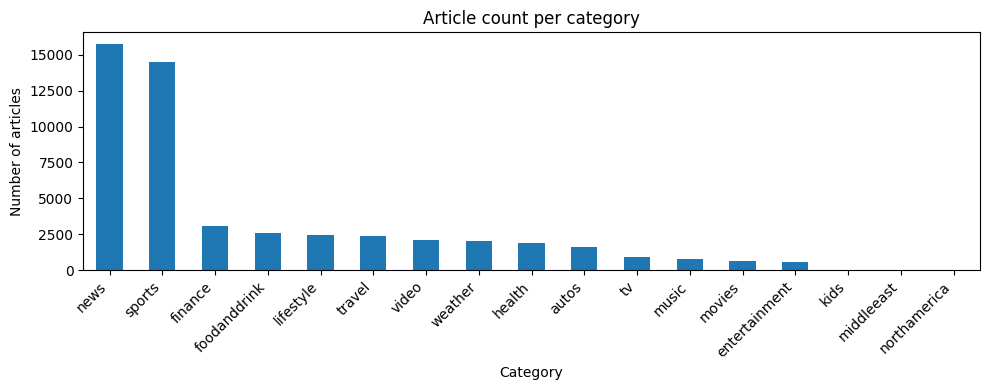

In [23]:
cat_counts = news["category"].value_counts()

print("Unique categories:", news["category"].nunique())
print()
print(cat_counts)

cat_counts.plot(kind="bar", figsize=(10, 4))
plt.title("Article count per category")
plt.xlabel("Category")
plt.ylabel("Number of articles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Subcategory distribution (top 20)

Subcategories give finer-grained topic signal. This is especially useful for content-based filtering — a user who reads "nfl" articles probably isn't interested in "lifestyleroyals".

Unique subcategories: 264

subcategory
newsus                      6564
football_nfl                5420
newspolitics                2826
newscrime                   2254
weathertopstories           2047
newsworld                   1720
football_ncaa               1665
baseball_mlb                1661
basketball_nba              1555
newsscienceandtechnology    1210
news                        1185
newstrends                  1176
more_sports                 1065
travelarticle               1042
travelnews                   902
lifestylebuzz                894
autosnews                    837
basketball_ncaa              774
financenews                  697
finance-real-estate          584
Name: count, dtype: int64


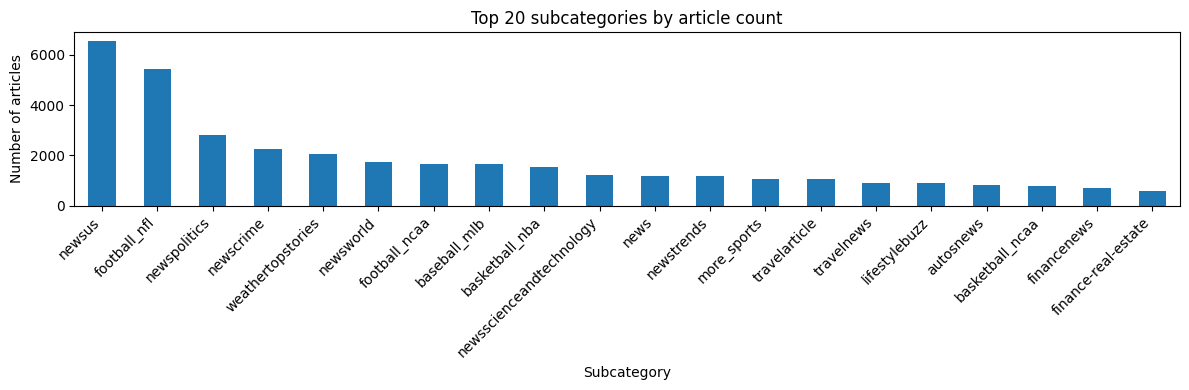

In [24]:
subcat_counts = news["subcategory"].value_counts().head(20)

print("Unique subcategories:", news["subcategory"].nunique())
print()
print(subcat_counts)

subcat_counts.plot(kind="bar", figsize=(12, 4))
plt.title("Top 20 subcategories by article count")
plt.xlabel("Subcategory")
plt.ylabel("Number of articles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Title and abstract length

Text length matters for NLP-based content models. Very short abstracts carry little signal; very long ones may need truncation. This also tells us whether title-only models are viable when abstracts are missing.

Title length (words):
count    51282.000000
mean        10.754417
std          3.265311
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         57.000000
Name: title_len, dtype: float64

Abstract length (words):
count    51282.000000
mean        34.293319
std         26.542819
min          0.000000
25%         15.000000
50%         24.000000
75%         62.000000
max        474.000000
Name: abstract_len, dtype: float64


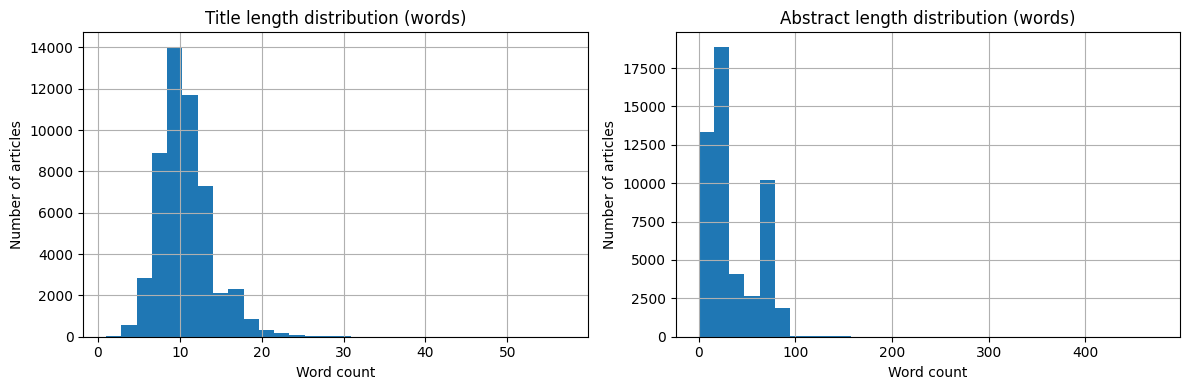

In [25]:
news["title_len"] = news["title"].fillna("").apply(lambda x: len(x.split()))
news["abstract_len"] = news["abstract"].fillna("").apply(lambda x: len(x.split()))

print("Title length (words):")
print(news["title_len"].describe())
print()
print("Abstract length (words):")
print(news["abstract_len"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
news["title_len"].hist(bins=30, ax=axes[0])
axes[0].set_title("Title length distribution (words)")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Number of articles")

news["abstract_len"].hist(bins=30, ax=axes[1])
axes[1].set_title("Abstract length distribution (words)")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Number of articles")

plt.tight_layout()
plt.show()

## Article coverage in behavior logs

Not all articles in news.tsv necessarily appear in the behavior logs. Coverage tells us:
- How many articles were ever shown to users (appeared as candidates)
- How many were actually clicked

Articles that were never shown are essentially dead weight for training. Articles that appear in behaviors but are missing from news.tsv are a data quality issue.

In [26]:
# Collect all news IDs that appeared as candidates in impressions
all_candidate_ids = set()
all_clicked_ids = set()

for imp in beh["impressions"]:
    for item in imp.split():
        nid, lbl = item.rsplit("-", 1)
        all_candidate_ids.add(nid)
        if lbl == "1":
            all_clicked_ids.add(nid)

# Also collect IDs from user history
all_history_ids = set()
for hist in beh["history"].dropna():
    for nid in hist.split():
        all_history_ids.add(nid)

news_ids_in_file = set(news["news_id"])

print(f"Articles in news.tsv:               {len(news_ids_in_file):>7}")
print(f"Unique articles shown as candidates: {len(all_candidate_ids):>7}")
print(f"Unique articles clicked:             {len(all_clicked_ids):>7}")
print(f"Unique articles in user history:     {len(all_history_ids):>7}")
print()

# Coverage
shown_and_in_file = all_candidate_ids & news_ids_in_file
shown_but_missing = all_candidate_ids - news_ids_in_file
in_file_but_not_shown = news_ids_in_file - all_candidate_ids

print(f"Candidates found in news.tsv:  {len(shown_and_in_file)} ({len(shown_and_in_file)/len(all_candidate_ids)*100:.1f}%)")
print(f"Candidates missing from news.tsv: {len(shown_but_missing)}")
print(f"News articles never shown as candidate: {len(in_file_but_not_shown)}")

Articles in news.tsv:                 51282
Unique articles shown as candidates:   20288
Unique articles clicked:                7713
Unique articles in user history:       33195

Candidates found in news.tsv:  20288 (100.0%)
Candidates missing from news.tsv: 0
News articles never shown as candidate: 30994


## Entity coverage

MIND provides named entity annotations for both title and abstract. These can enrich content representations. Here we check what fraction of articles have entity data and how many entities they contain on average.

In [27]:
def count_entities(entity_str):
    try:
        entities = json.loads(entity_str)
        return len(entities)
    except (json.JSONDecodeError, TypeError):
        return 0

news["n_title_entities"] = news["title_entities"].apply(count_entities)
news["n_abstract_entities"] = news["abstract_entities"].apply(count_entities)

print("Title entities:")
print(news["n_title_entities"].describe())
print(f"Articles with NO title entities: {(news['n_title_entities'] == 0).sum()} ({(news['n_title_entities'] == 0).mean()*100:.1f}%)")
print()
print("Abstract entities:")
print(news["n_abstract_entities"].describe())
print(f"Articles with NO abstract entities: {(news['n_abstract_entities'] == 0).sum()} ({(news['n_abstract_entities'] == 0).mean()*100:.1f}%)")

Title entities:
count    51282.000000
mean         1.168987
std          0.977183
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: n_title_entities, dtype: float64
Articles with NO title entities: 13845 (27.0%)

Abstract entities:
count    51282.000000
mean         1.858527
std          1.822684
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         30.000000
Name: n_abstract_entities, dtype: float64
Articles with NO abstract entities: 13829 (27.0%)


## Category click-through rates

Which categories are users most likely to click? This reveals whether some topics are inherently more engaging and helps set expectations for category-based content filtering.

                 shown  clicked       ctr
music           269008    15988  0.059433
tv              246462    14544  0.059011
weather          88646     4582  0.051689
sports          592226    28181  0.047585
video            93744     4262  0.045464
news           1591038    69408  0.043624
lifestyle       655440    26584  0.040559
finance         564671    20597  0.036476
health          304088    10863  0.035723
northamerica        29        1  0.034483
movies          132091     4186  0.031690
entertainment   349930    10530  0.030092
foodanddrink    369382    10883  0.029463
autos           271426     7428  0.027367
travel          315101     8304  0.026353
kids               162        3  0.018519


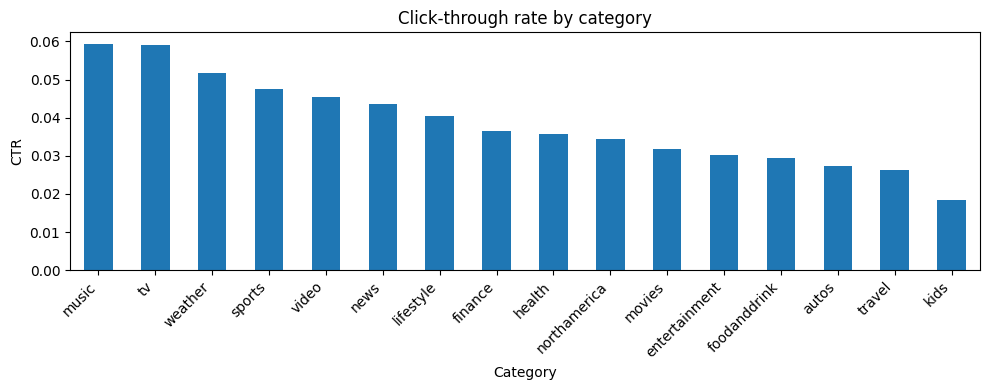

In [28]:
# Build a lookup: news_id -> category
id_to_cat = news.set_index("news_id")["category"].to_dict()

# For each impression, tally candidates shown and clicked per category
cat_shown = Counter()
cat_clicked = Counter()

for imp in beh["impressions"]:
    for item in imp.split():
        nid, lbl = item.rsplit("-", 1)
        cat = id_to_cat.get(nid, "unknown")
        cat_shown[cat] += 1
        if lbl == "1":
            cat_clicked[cat] += 1

cat_df = pd.DataFrame({
    "shown": pd.Series(cat_shown),
    "clicked": pd.Series(cat_clicked)
}).fillna(0)

cat_df["ctr"] = cat_df["clicked"] / cat_df["shown"]
cat_df = cat_df.sort_values("ctr", ascending=False)

print(cat_df)

cat_df["ctr"].plot(kind="bar", figsize=(10, 4))
plt.title("Click-through rate by category")
plt.xlabel("Category")
plt.ylabel("CTR")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()